In [ ]:
import re
import glob
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None

In [ ]:
model_name = lambda name: ' '.join(re.findall(r'([a-z]+)', name)[:2]).capitalize()
compute_duration = lambda x: x.max() - x.min()
def read_csv(paths: list) -> pd.DataFrame:
  df = pd.concat([ pd.read_csv(path) for path in paths])
  return df
Approach = dict(infaas="INFaaS", usher="Usher", roomie_heuristic_v2="Roomie")

In [97]:
WORKDIR = "JetsonNano/synthetic-data_logger_August_04_2025_2000"

In [ ]:
# for subdir in sorted(glob.glob(f"{WORKDIR}/*")):
#   qps = int(re.findall(r"agg(\d+)", subdir).pop())
#   print(f"| Query per second: {qps} |")
#   for approach in Approach:
#     df = read_csv(paths=glob.glob(f"{subdir}/{approach}/controller.csv"))
#     df["time"] = df["timestamp"] - df["timestamp"].min()
#     incoming_qps = df["time"].astype(int).value_counts().reset_index(name="count")["count"].median()
#     print(f"- {Approach[approach]}:\t{incoming_qps:.0f}")

| Query per second: 1000 |
- INFaaS:	1084
- Usher:	1089
- Roomie:	1088
| Query per second: 1500 |
- INFaaS:	1618
- Usher:	1616
- Roomie:	1611
| Query per second: 2000 |
- INFaaS:	2132
- Usher:	2129
- Roomie:	2128
| Query per second: 2500 |
- INFaaS:	2632
- Usher:	2618
- Roomie:	2607
| Query per second: 3000 |
- INFaaS:	3109
- Usher:	3127
- Roomie:	3099


In [100]:
data = []
factor = 100
for subdir in sorted(glob.glob(f"{WORKDIR}/*")):
  qps = int(re.findall(r"agg(\d+)", subdir).pop())
  for approach in Approach:
    # Throughput (queries send per second)
    df = read_csv(paths=glob.glob(f"{subdir}/{approach}/controller.csv"))
    throughput = len(df) / (df["timestamp"].max() - df["timestamp"].min())
    throughput = np.floor(throughput / factor) * factor
    # Goodput (queries processed per second)
    df = read_csv(paths=glob.glob(f"{subdir}/{approach}/*/worker*.csv"))
    goodput = df["batch_size"].sum() / (df["timestamp"].max() - df["timestamp"].min())
    # Aggregated goodput (goodput per model)
    # for approach in Approach:
    #   df_worker = pd.concat([pd.read_csv(path) for path in glob.glob(f"{directory}/{approach}/*/worker*.csv")])
    #   df_controller = pd.concat([pd.read_csv(path) for path in glob.glob(f"{directory}/{approach}/controller.csv")]).rename(columns={"app_id": "name"})
    #   max_duration = df_controller["at"].max()
    #   df_worker = df_worker[df_worker["at"] <= max_duration]
    #   df_worker = df_worker.groupby("name")["batch_size"].sum().reset_index().rename(columns={"batch_size": "goodput"})
    #   df_controller = df_controller["name"].value_counts().reset_index().rename(columns={"count": "throughput"})
    #   df = pd.merge(df_controller, df_worker, on="name")
    #   normalized_goodput = (df["goodput"] / df["throughput"]).mean()
    #   print(f"{approach}: {normalized_goodput:.2f}")
    
    # Response time
    avg_response_time = ((df["timestamp"] - df["in_sys_timestamp"]) / df["batch_size"]).mean()
    data += [{
      "qps": qps,
      "approach": Approach[approach],
      "throughput": throughput,
      "goodput": goodput,
      "avg_response_time": avg_response_time,
    }]
data = pd.DataFrame(data)
data.head()

,qps,approach,throughput,goodput,avg_response_time
0,1000,INFaaS,1000.0,460.880931,3.912639
1,1000,Usher,1000.0,469.121030,4.167793
2,1000,Roomie,1000.0,1078.266767,0.144741
3,1500,INFaaS,1500.0,645.263761,3.775245
4,1500,Usher,1500.0,478.355020,5.657460


# Goodput

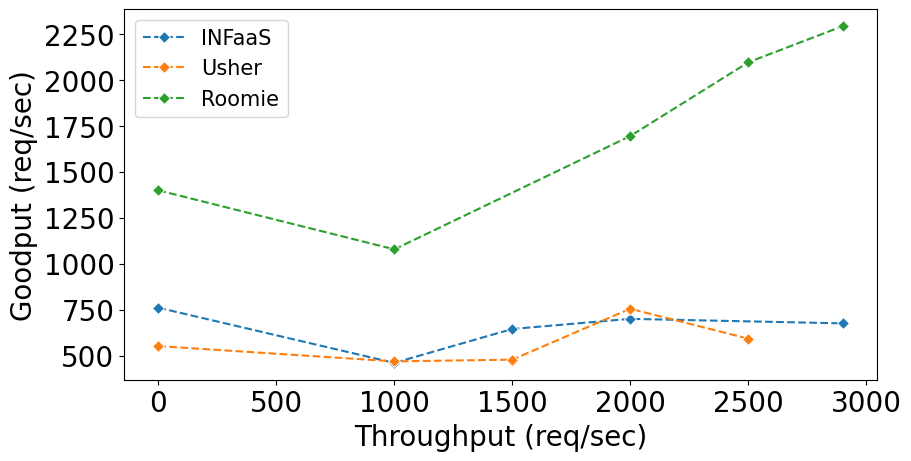

In [101]:
plt.figure(figsize=(9, 4.5), layout="constrained")
sns.lineplot(data, x="throughput", y="goodput", hue="approach", marker="D", linestyle="--")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Throughput (req/sec)", fontsize=20)
plt.ylabel("Goodput (req/sec)", fontsize=20)
plt.legend(fontsize=15)
plt.show()

# Response-Time

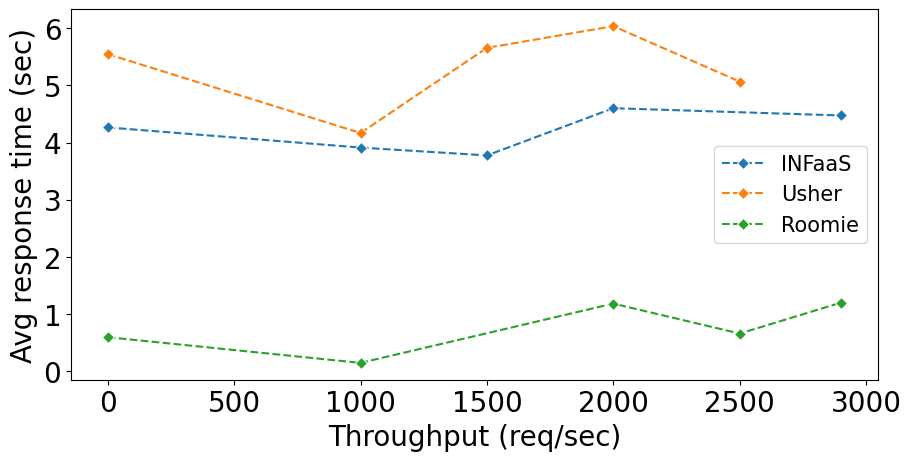

In [102]:
plt.figure(figsize=(9, 4.5), layout="constrained")
sns.lineplot(data, x="throughput", y="avg_response_time", hue="approach", marker="D", linestyle="--")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Throughput (req/sec)", fontsize=20)
plt.ylabel("Avg response time (sec)", fontsize=20)
plt.legend(fontsize=15)
plt.show()

# GPU Memory and Computation Utilization

In [103]:
columns = [
  'metrics-daemon/cuda:0 (gpu:0)/gpu_utilization (%)/mean',
  'metrics-daemon/cuda:1 (gpu:1)/gpu_utilization (%)/mean',
  'metrics-daemon/cuda:2 (gpu:2)/gpu_utilization (%)/mean',
  'metrics-daemon/cuda:3 (gpu:3)/gpu_utilization (%)/mean',
  ]

data = []
factor = 100
for subdir in sorted(glob.glob(f"{WORKDIR}/*")):
  qps = int(re.findall(r"agg(\d+)", subdir).pop())
  for approach in Approach:
    # Throughput (queries send per second)
    df = read_csv(paths=glob.glob(f"{subdir}/{approach}/controller.csv"))
    throughput = len(df) / (df["timestamp"].max() - df["timestamp"].min())
    throughput = int(np.floor(throughput / factor) * factor)
    # GPU utilization (%)
    df = read_csv(paths=glob.glob(f"{subdir}/{approach}/*/*gpu_trace.csv"))
    df["timestamp"] = df["time"].apply(lambda x: int(pd.to_datetime(x).timestamp()))
    start, end = df["timestamp"].min(), df["timestamp"].max()
    duration = end - start
    df = df[(df["timestamp"] >= (start + duration * .5)) & (df["timestamp"] <= (end - duration * .2))]
    try:
      avg_utilization = df["GPU"].mean()
    except:
      avg_utilization = np.mean([df[column].mean() for column in columns ])
    data += [{
      "qps": qps,
      "approach": Approach[approach],
      "throughput": throughput,
      "avg_utilization": avg_utilization,
    }]
data = pd.DataFrame(data)
data.head()    

,qps,approach,throughput,avg_utilization
0,1000,INFaaS,1000,13.790842
1,1000,Usher,1000,13.711814
2,1000,Roomie,1000,30.239895
3,1500,INFaaS,1500,12.877474
4,1500,Usher,1500,19.940000


# GPU Utilization

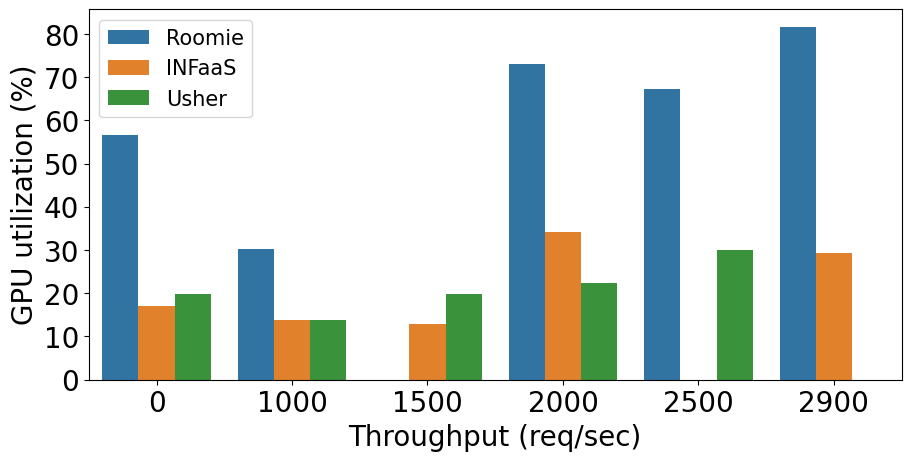

In [104]:
fig = plt.figure(figsize=(9, 4.5), layout="constrained")
sns.barplot(data, x="throughput", y="avg_utilization", hue="approach")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Throughput (req/sec)", fontsize=20)
plt.ylabel("GPU utilization (%)", fontsize=20)
plt.legend(fontsize=15)
plt.show()